# HealthConnect Clinic: Attandence vs No-Show Prediction

## Machine Learning Problem Definition Document / Notebook

**Project:** AnalystLab Africa Experience Lab — Data Science Track

**Author:** Ange Maxime

**Week:** 4 — Problem Definition & Data Assessment

**Dataset:** `HealthConnect_Appointment_Data.csv` (fictional, synthetic data)

**Supporting references:** `HealthConnect_Data_Dictionary.xlsx`, `HealthConnect_Clinic_Knowledge_Base.docx`

---

### Contents

1. [Problem Definition](#1)
2. [Data Loading & Initial Assessment](#2)
3. [Data Quality & Consistency Checks](#3)
4. [Exploratory Analysis Relative to the Target](#4)
5. [Proposed Target Variable](#5)
6. [Potential Input Features](#6)
7. [Handling Appointment Outcomes (Cancellations)](#7)
8. [Initial Modelling Approach](#8)
9. [Key Modelling Considerations](#9)
10. [Summary of Findings](#10)


In [1]:
1 + 1

2

<a id="1"></a>
## 1. Problem Definition

**Business context.** HealthConnect Clinic (fictional outpatient provider, two locations) loses clinical capacity and revenue every time a booked patient neither attends nor cancels in advance ("no-show"). Unused slots cannot be reallocated to other patients, clinicians' time is wasted, and waiting lists grow longer than necessary.

**Business objective.** Give clinic staff advance warning of appointments that are at high risk of becoming a no-show, early enough that they can act — e.g. send an extra reminder, call the patient, or overbook/reallocate the slot.

**Machine learning framing.** This is a **supervised, binary classification** problem at the level of an individual scheduled appointment:

> *Given everything that is known about an appointment at the time it is booked (or shortly before it takes place), predict whether the patient will attend or fail to attend without notice.*

The prediction must be made using only information that is genuinely available **before** the appointment happens

This constraint drives several of the feature and target decisions below.


## 📦 1. Setup & Package Loading

In [4]:
pip install openpyxl

ERROR: Could not find a version that satisfies the requirement openpyxl (from versions: none)
ERROR: No matching distribution found for openpyxl


Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 140)
sns.set_theme(style='whitegrid')

<a id="2"></a>
## 2. Data Loading & Initial Assessment

We start with a structural overview: data types, missing values, duplicates, and the shape/balance of the target column, cross-checked against the supplied data dictionary.


In [9]:
df = pd.read_csv('C:/Users/Ange/Downloads/Training Data S. africa Lab/week 4/Data/HealthConnect_Appointment_Data.csv')
print(f"Appointment data: {df.shape[0]:,} rows, {df.shape[1]} columns")
df.head()

Appointment data: 5,000 rows, 18 columns


,appointment_id,patient_id,gender,age,age_group,appointment_type,booking_date,appointment_date,appointment_day,appointment_time,booking_lead_days,previous_appointments,previous_no_shows,reminder_sent,reminder_channel,distance_to_clinic_km,waiting_time_minutes,appointment_outcome
0,HC-00001,P-1613,Female,39,35-44,Follow-up,2/6/2025,2/18/2025,Tuesday,Afternoon,12,2,0,Yes,WhatsApp,19.3,29.0,No-Show
1,HC-00002,P-0813,Male,31,25-34,Specialist Consultation,2/25/2026,2/27/2026,Friday,Morning,2,6,0,Yes,SMS,14.3,42.0,Attended
2,HC-00003,P-1366,Female,50,45-54,General Consultation,11/16/2025,12/24/2025,Wednesday,Morning,38,5,1,Yes,SMS,11.4,11.0,No-Show
3,HC-00004,P-1031,Male,59,55-64,Follow-up,7/18/2025,8/28/2025,Thursday,Evening,41,3,1,Yes,SMS,7.4,35.0,Attended
4,HC-00005,P-1458,Female,34,25-34,Follow-up,7/9/2025,8/25/2025,Monday,Afternoon,47,3,1,Yes,Email,5.6,27.0,No-Show


In [11]:
dict_df = pd.read_excel('C:/Users/Ange/Downloads/Training Data S. africa Lab/week 4/Data/HealthConnect_Data_Dictionary.xlsx')
print(f"Data dictionary: {dict_df.shape[0]} variables defined")

ImportError: Missing optional dependency 'openpyxl'.  Use pip or conda to install openpyxl.

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   appointment_id         5000 non-null   object 
 1   patient_id             5000 non-null   object 
 2   gender                 5000 non-null   object 
 3   age                    5000 non-null   int64  
 4   age_group              5000 non-null   object 
 5   appointment_type       5000 non-null   object 
 6   booking_date           5000 non-null   object 
 7   appointment_date       5000 non-null   object 
 8   appointment_day        5000 non-null   object 
 9   appointment_time       5000 non-null   object 
 10  booking_lead_days      5000 non-null   int64  
 11  previous_appointments  5000 non-null   int64  
 12  previous_no_shows      5000 non-null   int64  
 13  reminder_sent          5000 non-null   object 
 14  reminder_channel       3634 non-null   object 
 15  dist

In [ ]:
dict_df

: 

In [13]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_summary = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
missing_summary[missing_summary['missing_count'] > 0].sort_values('missing_count', ascending=False)

,missing_count,missing_pct
reminder_channel,1366,27.32
distance_to_clinic_km,90,1.80
waiting_time_minutes,60,1.20


Three columns carry missing values:

- **`reminder_channel`** - missing for every row where `reminder_sent == 'No'` (verified below). This is *structural* missingness, not random: the channel simply does not exist when no reminder was sent. It should be encoded as an explicit category (e.g. `"None"`) rather than imputed.
  
- **`distance_to_clinic_km`** (~1.8%) and **`waiting_time_minutes`** (~1.2%) — small amounts of missingness consistent with the data dictionary's note ("contains limited missing values"). Low enough to handle with simple imputation (median) or a missing-indicator flag without materially affecting the analysis.


In [14]:
pd.crosstab(df['reminder_sent'], df['reminder_channel'].isnull(), rownames=['reminder_sent'], colnames=['reminder_channel is missing'])

reminder_channel is missing,False,True
reminder_sent,,
No,0,1366
Yes,3634,0


In [15]:
print("Fully duplicated rows:", df.duplicated().sum())
print("Duplicate appointment_id values:", df['appointment_id'].duplicated().sum())
print("Unique patients:", df['patient_id'].nunique(), " out of ", len(df), "appointment rows")
df['patient_id'].value_counts().describe()

Fully duplicated rows: 0
Duplicate appointment_id values: 0
Unique patients: 1696  out of  5000 appointment rows


count    1696.000000
mean        2.948113
std         1.521029
min         1.000000
25%         2.000000
50%         3.000000
75%         4.000000
max         9.000000
Name: count, dtype: float64

**No duplicate rows or duplicate appointment IDs**: each row is a distinct appointment. 

However, only **1,696 unique patients** generate **5,000 appointments** (a patient appears 2.9 times on average, up to 9 times). This repetition is important for modelling: rows from the same patient are not independent, which affects how we split data for training/validation (see §8).


appointment_outcome
No-Show      2423
Attended     2314
Cancelled     263
Name: count, dtype: int64

appointment_outcome
No-Show      48.5%
Attended     46.3%
Cancelled     5.3%
Name: proportion, dtype: object


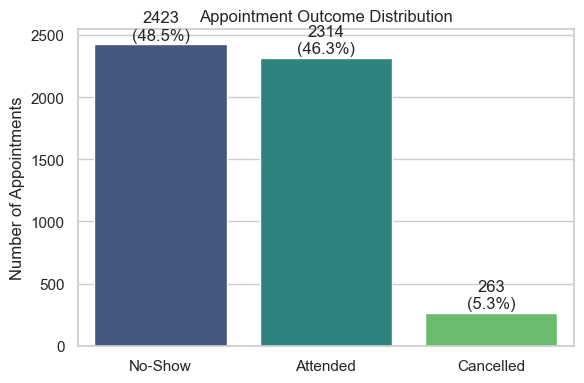

In [16]:
target_counts = df['appointment_outcome'].value_counts()
target_pct = df['appointment_outcome'].value_counts(normalize=True).mul(100).round(1)
print(target_counts)
print()
print(target_pct.astype(str) + '%')

fig, ax = plt.subplots(figsize=(6,4))
sns.barplot(x=target_counts.index, y=target_counts.values, hue=target_counts.index,
            palette='viridis', legend=False, ax=ax)
ax.set_title('Appointment Outcome Distribution')
ax.set_ylabel('Number of Appointments')
ax.set_xlabel('')
for i, v in enumerate(target_counts.values):
    ax.text(i, v + 40, f"{v}\n({target_pct.values[i]}%)", ha='center')
plt.tight_layout()
plt.show()

The outcome is close to a **three-way split**: 48.5% No-Show, 46.3% Attended, and a small 5.3% Cancelled minority. 

Attended vs. No-Show is roughly balanced (no severe class imbalance to correct for on that axis), but Cancelled is a small class that needs a deliberate design decision (§7).


In [17]:
df.describe(include='number').T

,count,mean,std,min,25%,50%,75%,max
age,5000.0,48.794800,18.138547,18.0,33.0,49.0,64.0,80.0
booking_lead_days,5000.0,29.638600,17.399360,0.0,15.0,30.0,45.0,60.0
previous_appointments,5000.0,3.013800,1.741211,0.0,2.0,3.0,4.0,11.0
previous_no_shows,5000.0,0.544200,0.746832,0.0,0.0,0.0,1.0,5.0
distance_to_clinic_km,4910.0,10.109572,6.590030,0.5,5.3,8.7,13.5,45.0
waiting_time_minutes,4940.0,24.189676,10.863184,2.0,17.0,24.0,32.0,68.0


In [18]:
df.describe(include='object').T

,count,unique,top,freq
appointment_id,5000,5000,HC-05000,1
patient_id,5000,1696,P-1742,9
gender,5000,3,Female,2488
age_group,5000,6,65+,1241
appointment_type,5000,4,General Consultation,2086
booking_date,5000,593,8/24/2025,20
appointment_date,5000,545,3/14/2026,18
appointment_day,5000,7,Wednesday,737
appointment_time,5000,3,Morning,2227
reminder_sent,5000,2,Yes,3634


<a id="3"></a>
## 3. Data Quality & Consistency Checks

Beyond missing values and duplicates, we validate the internal logical consistency of the dataset and cross-check it against the operational rules in the **Clinic Knowledge Base** (opening hours, policies). These checks matter because a no-show model is only trustworthy if the data that trains it is trustworthy.


In [19]:
# Parse dates
df['booking_date_dt'] = pd.to_datetime(df['booking_date'], format='%m/%d/%Y')
df['appointment_date_dt'] = pd.to_datetime(df['appointment_date'], format='%m/%d/%Y')

# 1. booking_lead_days should equal appointment_date - booking_date
calc_lead = (df['appointment_date_dt'] - df['booking_date_dt']).dt.days
lead_mismatches = (calc_lead != df['booking_lead_days']).sum()
negative_lead = (calc_lead < 0).sum()
print(f"booking_lead_days mismatches vs recalculated value: {lead_mismatches}")
print(f"Appointments booked AFTER the appointment date (negative lead time): {negative_lead}")

# 2. appointment_day should match the actual weekday of appointment_date
calc_weekday = df['appointment_date_dt'].dt.day_name()
day_mismatches = (calc_weekday != df['appointment_day']).sum()
print(f"appointment_day mismatches vs recalculated weekday: {day_mismatches}")

# 3. previous_no_shows should never exceed previous_appointments
bad_history = (df['previous_no_shows'] > df['previous_appointments']).sum()
print(f"Rows where previous_no_shows > previous_appointments: {bad_history}")

# 4. age vs age_group consistency
def expected_band(age):
    if age <= 24: return '18-24'
    if age <= 34: return '25-34'
    if age <= 44: return '35-44'
    if age <= 54: return '45-54'
    if age <= 64: return '55-64'
    return '65+'
age_mismatches = (df['age'].apply(expected_band) != df['age_group']).sum()
print(f"age / age_group mismatches: {age_mismatches}")

print(f"\nDate ranges — booking: {df['booking_date_dt'].min().date()} to {df['booking_date_dt'].max().date()}")
print(f"Date ranges — appointment: {df['appointment_date_dt'].min().date()} to {df['appointment_date_dt'].max().date()}")

booking_lead_days mismatches vs recalculated value: 0
Appointments booked AFTER the appointment date (negative lead time): 0
appointment_day mismatches vs recalculated weekday: 0
Rows where previous_no_shows > previous_appointments: 0
age / age_group mismatches: 0

Date ranges — booking: 2024-11-07 to 2026-06-27
Date ranges — appointment: 2025-01-01 to 2026-06-30


**Derived/engineered fields are internally consistent**: `booking_lead_days`, `appointment_day`, and `age_group` all agree perfectly with what can be recalculated from `booking_date`, `appointment_date`, and `age`, and no patient has more historical no-shows than historical appointments. 

This is expected of a curated synthetic dataset, but it is exactly the kind of check that must never be skipped on real clinic data, where such inconsistencies are common.

Two findings **do** need to be flagged as data-quality issues to resolve with the project/business owner before modelling:


In [20]:
# Sunday appointments, even though the knowledge base states the clinic is closed on Sundays
sunday_appts = (calc_weekday == 'Sunday').sum()
print(f"Appointments scheduled on a Sunday: {sunday_appts} ({sunday_appts/len(df):.1%} of all rows)")
df.loc[calc_weekday == 'Sunday', ['appointment_id','appointment_date','appointment_day','appointment_outcome']].head()

Appointments scheduled on a Sunday: 737 (14.7% of all rows)


,appointment_id,appointment_date,appointment_day,appointment_outcome
6,HC-00007,2/16/2025,Sunday,No-Show
29,HC-00030,8/31/2025,Sunday,No-Show
38,HC-00039,6/1/2025,Sunday,Cancelled
42,HC-00043,1/18/2026,Sunday,Attended
43,HC-00044,7/13/2025,Sunday,No-Show


**Issue A — Sunday appointments.** The Clinic Knowledge Base states the clinic is *closed on Sundays and public holidays*, yet **737 appointments (14.7%)** in the dataset fall on a Sunday. 

This is a business-rule violation: either (a) these rows represent a data-generation artefact that should be corrected/removed, or (b) the "closed Sunday" policy does not reflect actual operating history and the knowledge base is out of date. 

his should be confirmed with the clinic before the feature `appointment_day` (or a derived `is_weekend` feature) is trusted at face value.


In [21]:
# waiting_time_minutes recorded even for appointments that were never attended
not_attended = df[df['appointment_outcome'] != 'Attended']
print(f"No-Show / Cancelled appointments with a non-null waiting_time_minutes: "
      f"{not_attended['waiting_time_minutes'].notna().sum()} out of {len(not_attended)}")

print(df.groupby('appointment_outcome')['waiting_time_minutes'].describe()[['count','mean','std','min','max']])

No-Show / Cancelled appointments with a non-null waiting_time_minutes: 2647 out of 2686
                      count       mean        std  min   max
appointment_outcome                                         
Attended             2293.0  24.289141  10.946389  2.0  68.0
Cancelled             261.0  23.214559  10.557896  2.0  55.0
No-Show              2386.0  24.200754  10.814945  2.0  67.0


**Issue B - `waiting_time_minutes` has ambiguous semantics.** The data dictionary describes it as "Estimated waiting time," but its distribution is essentially identical across Attended, No-Show, and Cancelled appointments (~24 minutes on average in all three groups), and it is populated for patients who never showed up. Two readings are possible:

- If this is a **pre-appointment estimate** (e.g. an expected queue time shown to the patient at booking), it is a legitimate feature — but its lack of relationship with the outcome suggests it may carry little predictive value.
- If it is actually an **observed, post-visit** waiting time, it cannot be known at prediction time for a future appointment and must be **excluded as a target-leakage risk** — a model should never be trained on information that would not exist yet when the prediction is actually needed.

We treat this as a leakage risk by default (excluded from the initial feature set) until the business/data-engineering team confirms when this value is actually captured.


In [22]:
# reminder logic sanity check (already partly shown above) and value ranges
print("reminder_sent values:", df['reminder_sent'].unique())
print("reminder_channel values:", df['reminder_channel'].dropna().unique())
print("gender values:", df['gender'].unique())
print("appointment_type values:", df['appointment_type'].unique())
print("appointment_time values:", df['appointment_time'].unique())
print()
print("Any negative distance/waiting/age/lead values?",
      (df[['distance_to_clinic_km','waiting_time_minutes','age','booking_lead_days']] < 0).any().any())

reminder_sent values: ['Yes' 'No']
reminder_channel values: ['WhatsApp' 'SMS' 'Email']
gender values: ['Female' 'Male' 'Prefer not to say']
appointment_type values: ['Follow-up' 'Specialist Consultation' 'General Consultation'
 'Diagnostic Test']
appointment_time values: ['Afternoon' 'Morning' 'Evening']

Any negative distance/waiting/age/lead values? False


No negative or otherwise impossible values were found in the numeric columns, and all categorical fields contain only the categories documented in the data dictionary (no free-text or stray values). Reminder logic is 100% consistent: every "No" for `reminder_sent` has a null `reminder_channel`, and every "Yes" has one populated.

**Summary of data quality:** the dataset is well-structured, has no duplicate records, minimal missingness, and internally consistent engineered fields. The main items to resolve before or during modelling are the Sunday-appointment anomaly and the ambiguous timing of `waiting_time_minutes`.


<a id="4"></a>
## 4. Exploratory Analysis Relative to the Target

We look at how the outcome varies across the candidate predictors, focusing on the No-Show rate (Cancelled and Attended appointments held out momentarily, see §7 for how they are ultimately handled).


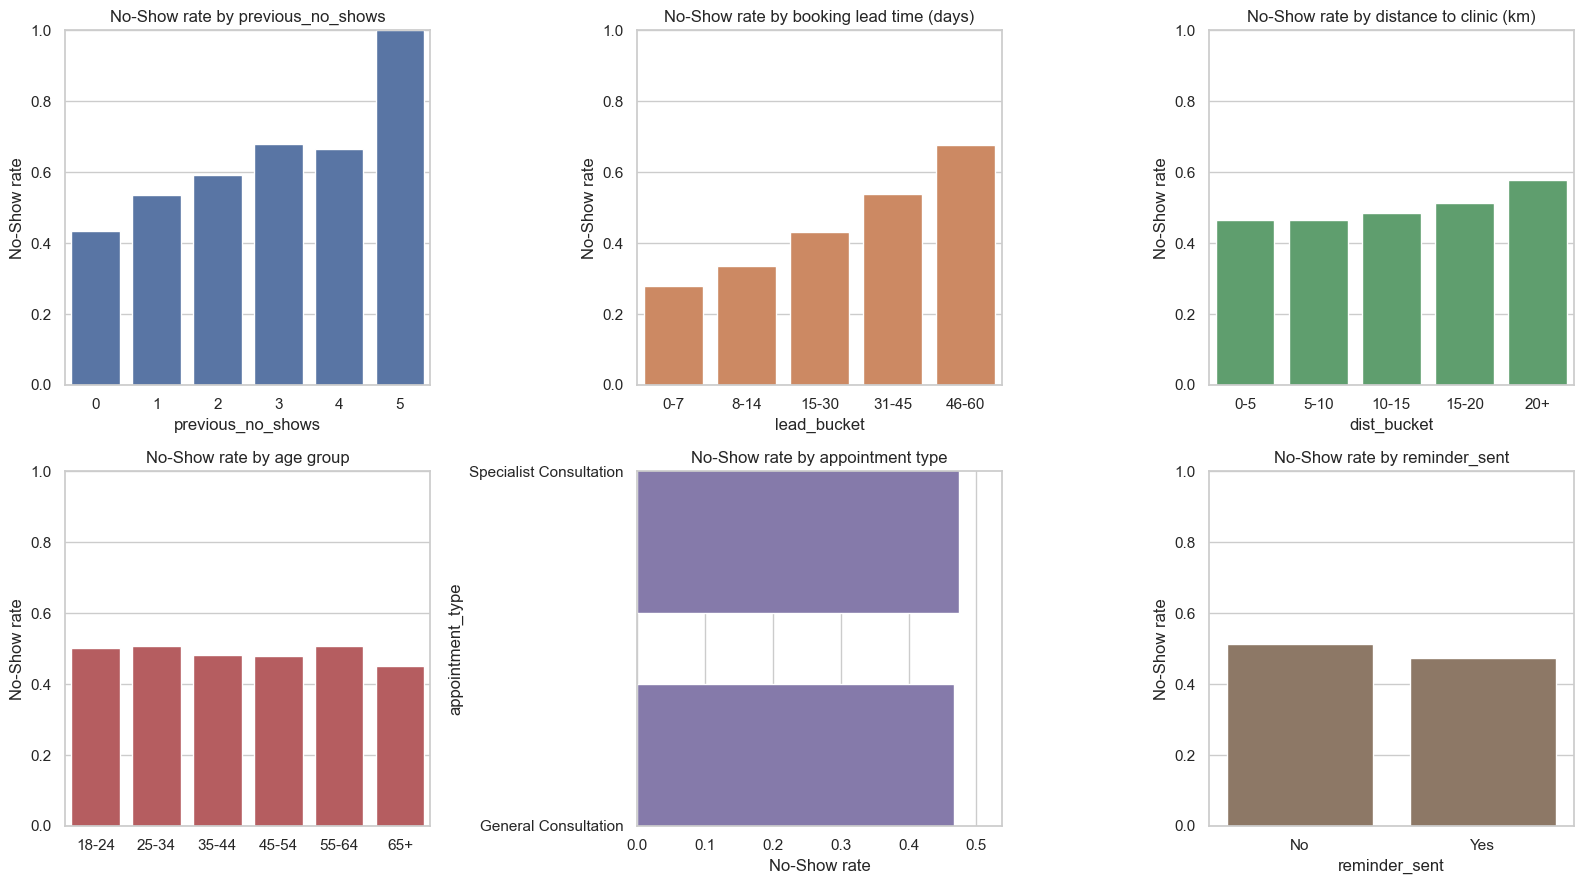

In [23]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

# previous_no_shows
rate_by_prev = df.groupby('previous_no_shows')['appointment_outcome'].apply(lambda x: (x=='No-Show').mean())
sns.barplot(x=rate_by_prev.index, y=rate_by_prev.values, ax=axes[0,0], color='#4C72B0')
axes[0,0].set_title('No-Show rate by previous_no_shows')
axes[0,0].set_ylabel('No-Show rate')

# booking_lead_days (bucketed)
df['lead_bucket'] = pd.cut(df['booking_lead_days'], bins=[-1,7,14,30,45,60],
                            labels=['0-7','8-14','15-30','31-45','46-60'])
rate_by_lead = df.groupby('lead_bucket', observed=True)['appointment_outcome'].apply(lambda x: (x=='No-Show').mean())
sns.barplot(x=rate_by_lead.index, y=rate_by_lead.values, ax=axes[0,1], color='#DD8452')
axes[0,1].set_title('No-Show rate by booking lead time (days)')
axes[0,1].set_ylabel('No-Show rate')

# distance
df['dist_bucket'] = pd.cut(df['distance_to_clinic_km'], bins=[0,5,10,15,20,50],
                            labels=['0-5','5-10','10-15','15-20','20+'])
rate_by_dist = df.groupby('dist_bucket', observed=True)['appointment_outcome'].apply(lambda x: (x=='No-Show').mean())
sns.barplot(x=rate_by_dist.index, y=rate_by_dist.values, ax=axes[0,2], color='#55A868')
axes[0,2].set_title('No-Show rate by distance to clinic (km)')
axes[0,2].set_ylabel('No-Show rate')

# age_group
rate_by_age = df.groupby('age_group', observed=True)['appointment_outcome'].apply(lambda x: (x=='No-Show').mean())
order = ['18-24','25-34','35-44','45-54','55-64','65+']
sns.barplot(x=order, y=rate_by_age.reindex(order).values, ax=axes[1,0], color='#C44E52')
axes[1,0].set_title('No-Show rate by age group')
axes[1,0].set_ylabel('No-Show rate')

# appointment_type
rate_by_type = df.groupby('appointment_type')['appointment_outcome'].apply(lambda x: (x=='No-Show').mean()).sort_values()
sns.barplot(x=rate_by_type.values, y=rate_by_type.index, ax=axes[1,1], color='#8172B2')
axes[1,1].set_title('No-Show rate by appointment type')
axes[1,1].set_xlabel('No-Show rate')

# reminder_sent
rate_by_rem = df.groupby('reminder_sent')['appointment_outcome'].apply(lambda x: (x=='No-Show').mean())
sns.barplot(x=rate_by_rem.index, y=rate_by_rem.values, ax=axes[1,2], color='#937860')
axes[1,2].set_title('No-Show rate by reminder_sent')
axes[1,2].set_ylabel('No-Show rate')

for ax in axes.flat:
    ax.set_ylim(0, 1)

plt.tight_layout()
plt.show()

**Observations:**

- **`previous_no_shows` shows a strong, monotonic relationship** with the No-Show rate: patients with 0 prior no-shows sit around 44%, rising to ~68% at 3-4 prior no-shows. This is expected to be one of the strongest predictors — past behaviour predicting future behaviour.
  
- **`booking_lead_days` shows the strongest gradient of all**: No-Show rate roughly triples from ~28% for same-week bookings to ~68% for appointments booked 46-60 days out. Appointments booked far in advance are much more likely to be forgotten or overtaken by events.
  
- **`distance_to_clinic_km`** shows a mild upward trend at longer distances (~46% nearby, rising to ~58% beyond 20km) — plausibly a real logistical effect (harder to get to the clinic).
  
- **`age_group`, `appointment_type`, and `reminder_sent`** show comparatively **weak** differences (all rates cluster in the 45-51% range). `reminder_sent` in particular is *counter-intuitive at first glance* (rate is not much lower when a reminder was sent) — this deserves a closer, multivariate look during modelling rather than being dismissed, since reminders may be sent selectively to patients already flagged as high-risk (a confound), or the reminder itself may genuinely have limited effect in this synthetic dataset.


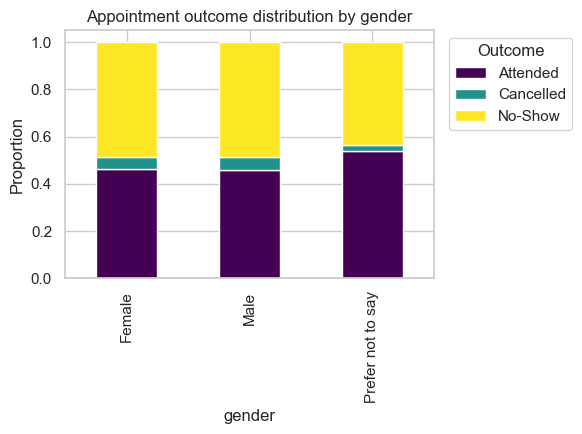

In [24]:
fig, ax = plt.subplots(figsize=(6,4.5))
ct = pd.crosstab(df['gender'], df['appointment_outcome'], normalize='index')
ct.plot(kind='bar', stacked=True, ax=ax, colormap='viridis')
ax.set_title('Appointment outcome distribution by gender')
ax.set_ylabel('Proportion')
ax.legend(title='Outcome', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

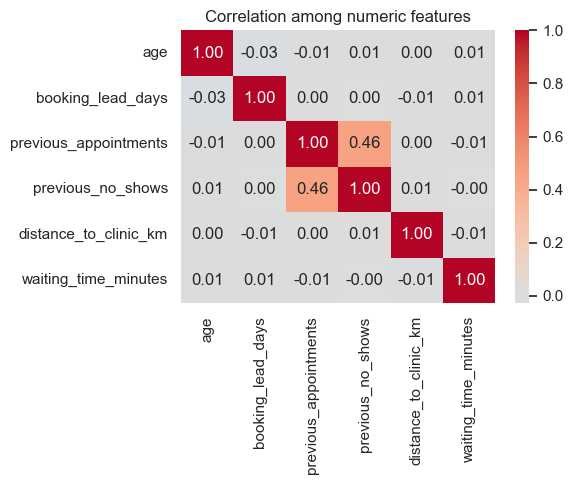

In [25]:
numeric_cols = ['age','booking_lead_days','previous_appointments','previous_no_shows',
                 'distance_to_clinic_km','waiting_time_minutes']
corr = df[numeric_cols].corr()
fig, ax = plt.subplots(figsize=(6,5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Correlation among numeric features')
plt.tight_layout()
plt.show()

No strong multicollinearity among the numeric features — `previous_appointments` and `previous_no_shows` show a modest positive correlation (patients with a longer appointment history naturally have more chances to have missed one), which is expected and not a concern for most model types.


<a id="5"></a>
## 5. Proposed Target Variable

The raw `appointment_outcome` column has three levels: **Attended**, **No-Show**, **Cancelled**. The business objective (§1) is specifically to flag patients who will fail to show up *without any notice*, which is a different operational problem from a patient who proactively cancels. We therefore propose a **derived binary target**:

```
target = 1  if appointment_outcome == 'No-Show'
target = 0  if appointment_outcome == 'Attended'
```

with **Cancelled appointments handled separately** rather than folded into either class by default (full reasoning and alternatives in §7). This keeps the target semantically clean: *"will this patient simply not turn up, with no warning to the clinic?"* — the scenario that actually wastes a slot with zero lead time to react.


In [26]:
binary_df = df[df['appointment_outcome'].isin(['Attended','No-Show'])].copy()
binary_df['target'] = (binary_df['appointment_outcome'] == 'No-Show').astype(int)
print(f"Rows retained for the primary binary target: {len(binary_df):,} of {len(df):,}")
print(binary_df['target'].value_counts(normalize=True).round(3))

Rows retained for the primary binary target: 4,737 of 5,000
target
1    0.512
0    0.488
Name: proportion, dtype: float64


On the Attended-vs-No-Show subset the classes are close to balanced (~51% / 49%), which is a favourable starting point — we won't need aggressive resampling, though we will still track precision/recall separately rather than relying on accuracy alone (§8-9).


<a id="6"></a>
## 6. Potential Input Features

Features are grouped below, with an explicit call on whether each is safe to use for a **pre-appointment** prediction (i.e. known at, or shortly after, booking time).

| Group | Candidate features | Available at prediction time? |
|---|---|---|
| **Patient demographics** | `gender`, `age` / `age_group` | Yes |
| **Appointment characteristics** | `appointment_type`, `appointment_time`, `appointment_day` (derived) | Yes |
| **Scheduling behaviour** | `booking_lead_days`, day-of-week/season derived from `booking_date` & `appointment_date` | Yes |
| **Patient history** | `previous_appointments`, `previous_no_shows`, and a derived **historical no-show rate** (`previous_no_shows / previous_appointments`, with a rule for patients with 0 history) | Yes |
| **Logistics** | `distance_to_clinic_km` | Yes |
| **Communication** | `reminder_sent`, `reminder_channel` | Yes, provided this is decided/logged at or before booking rather than adjusted afterwards |
| **Identifiers** | `appointment_id`, `patient_id` | Not as direct model inputs (pure identifiers) — `patient_id` is useful for grouping in cross-validation and for building the historical-rate feature, but should not be one-hot encoded as a feature itself (too high-cardinality, would just memorise individual patients) |
| **Excluded — leakage risk** | `waiting_time_minutes` | **No** — ambiguous/likely post-visit measurement (Issue B, §3); excluded from the initial feature set pending clarification |
| **Flag before use** | `appointment_day`, `is_weekend` | Usable, but see the Sunday-appointment anomaly (Issue A, §3) — confirm the underlying dates/policy before trusting a weekend effect |

**Proposed initial feature set** (first modelling pass):
`gender`, `age`, `appointment_type`, `appointment_time`, `appointment_day`, `booking_lead_days`, `previous_appointments`, `previous_no_shows`, `historical_no_show_rate` (engineered), `distance_to_clinic_km`, `reminder_sent`, `reminder_channel`.


In [27]:
# Illustrative feature engineering — historical no-show rate
binary_df['historical_no_show_rate'] = np.where(
    binary_df['previous_appointments'] > 0,
    binary_df['previous_no_shows'] / binary_df['previous_appointments'],
    0.0  # no history yet -> treat as neutral / cold-start default
)
binary_df[['patient_id','previous_appointments','previous_no_shows','historical_no_show_rate']].head()

,patient_id,previous_appointments,previous_no_shows,historical_no_show_rate
0,P-1613,2,0,0.000000
1,P-0813,6,0,0.000000
2,P-1366,5,1,0.200000
3,P-1031,3,1,0.333333
4,P-1458,3,1,0.333333


<a id="7"></a>
## 7. Handling Appointment Outcomes (Cancellations)

Cancelled appointments (5.3% of rows) are a **small but operationally distinct** class: the patient took an action (contacted the clinic in advance, per the Knowledge Base's cancellation policy) rather than silently failing to appear. Three options were considered:

1. **Exclude cancellations, binary Attended vs. No-Show (recommended for the first iteration).** Cleanest signal, matches the stated business objective exactly, and avoids forcing a proactive cancellation to look like either a "success" or a "failure." Downside: the model gives no guidance on the ~5% of appointments that get cancelled, and in deployment the model must still be paired with simple, separate logic for handling those (e.g. they are already known to the clinic and don't need a no-show flag).

2. **Three-class classification (Attended / No-Show / Cancelled).** More complete picture, but the Cancelled class is small (263 rows) relative to the other two, so it would need class-imbalance handling and produces a harder, less directly actionable output for a first iteration.

3. **Fold Cancelled into No-Show** (both represent an "unused slot"). Operationally tempting, but conflates two different behaviours (a patient who calls ahead is not the same risk profile as one who simply doesn't come), and would bias the model to primarily learn cancellation patterns if they differ systematically from no-show patterns.

**Recommendation:** proceed with **Option 1** for the Week 4/5 baseline model, and revisit Option 2 as a stretch goal once a solid binary baseline exists — a separate lightweight "will this patient cancel" signal could complement, rather than replace, the no-show model.


<a id="8"></a>
## 8. Initial Modelling Approach

**Unit of analysis:** one row per scheduled appointment.

**Train / validation / test split.** Because the same `patient_id` can appear in multiple rows (§2), a naive random row-level split would let information about a patient leak between training and test sets (the model could partly "memorise" a patient it has already seen). We propose a **patient-grouped split** (e.g. `GroupShuffleSplit` / `GroupKFold` on `patient_id`), so that all appointments for a given patient fall entirely within one split. Given `booking_date`/`appointment_date` are available, a **time-based split** (train on earlier appointments, validate/test on later ones) is also worth comparing, since it better simulates the real deployment scenario of predicting future appointments from past history.

**Baseline models (in increasing complexity):**
- **Majority-class / rate-based baseline** — always predict the more frequent class, or predict using only `historical_no_show_rate`, purely to set a floor that any real model must beat.
- **Logistic Regression** — simple, interpretable, gives clinic staff a transparent view of which factors drive risk (useful given this is a service-delivery context where explainability to non-technical staff matters).
- **Tree-based ensembles (Random Forest / Gradient Boosting, e.g. `scikit-learn`'s `RandomForestClassifier` or `HistGradientBoostingClassifier`)** — expected to handle the non-linear effects already visible in §4 (e.g. the steep `booking_lead_days` gradient) better than a linear model.

**Preprocessing pipeline (planned for Week 5):**
- Categorical variables (`gender`, `appointment_type`, `appointment_time`, `appointment_day`, `reminder_sent`, `reminder_channel`) → one-hot / ordinal encoding as appropriate.
- Numeric variables → median imputation for `distance_to_clinic_km` (small missing %), with a missing-indicator flag retained as a feature in case missingness itself is informative.
- `reminder_channel` missing → explicit `"None"` category (structural, not random).
- All steps wrapped in an `sklearn.Pipeline` fitted only on the training fold, to avoid any leakage from validation/test data into preprocessing statistics (e.g. imputation medians).

**Evaluation metrics.** Given the roughly balanced classes but a real operational asymmetry between error types (a missed high-risk patient costs a wasted slot; a false alarm costs one unnecessary follow-up call), we propose tracking, in order of priority:
- **Recall on the No-Show class** (catch as many true no-shows as possible) alongside **precision** (avoid excessive false alarms that would erode staff trust in the tool).
- **ROC-AUC / PR-AUC** for overall ranking quality, since the clinic may prefer a risk *score* they can threshold operationally (e.g. "call the top 15% highest-risk patients") rather than a hard yes/no label.
- Accuracy is reported for context only, given it is a weak metric on its own even for a near-balanced target.


In [28]:
# Illustrative: what a patient-grouped split preserves vs. a naive random split
from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(binary_df, groups=binary_df['patient_id']))

train_patients = set(binary_df.iloc[train_idx]['patient_id'])
test_patients = set(binary_df.iloc[test_idx]['patient_id'])

print(f"Train rows: {len(train_idx):,}   Test rows: {len(test_idx):,}")
print(f"Patients appearing in BOTH train and test (should be 0): {len(train_patients & test_patients)}")
print(f"Train target rate: {binary_df.iloc[train_idx]['target'].mean():.3f}   "
      f"Test target rate: {binary_df.iloc[test_idx]['target'].mean():.3f}")

Train rows: 3,771   Test rows: 966
Patients appearing in BOTH train and test (should be 0): 0
Train target rate: 0.514   Test target rate: 0.500


<a id="9"></a>
## 9. Key Modelling Considerations

- **Synthetic data caveat.** The dataset is explicitly fictional/synthetic (per the Clinic Knowledge Base). Relationships that look strong here (e.g. `booking_lead_days`) should be validated against real operational data before being relied on in production — synthetic generation processes can bake in stronger or cleaner signal than reality provides.
  
- **Leakage discipline.** `waiting_time_minutes` is excluded pending clarification (§3, Issue B); any future feature must be checked against the question *"would this value actually be known before the appointment happens?"* before being added.
  
- **Data quality follow-up.** The Sunday-appointment anomaly (§3, Issue A) should be resolved with the business/data owner — it may indicate a data-generation issue, an outdated knowledge-base policy, or a legitimate but undocumented exception (e.g. urgent slots).
  
- **Non-independence of rows.** Repeated patients (§2) mean standard random cross-validation will overestimate performance; grouped or time-based splitting is required (§8).
  
- **Class handling for Cancelled outcomes.** The Week 4 recommendation (§7) is to exclude cancellations from the primary model; this decision should be revisited with stakeholders, since a deployed system will still encounter cancellations and needs a defined behaviour for them.
  
- **Fairness and appropriate use.** `gender` and `age` are demographic attributes; even though their bivariate relationship with the outcome was weak (§4), any deployed model should be checked for differential error rates across these groups before being used to influence how patients are treated (e.g. differential outreach), consistent with the Knowledge Base's emphasis on the assistant being administrative/informational only, not a basis for clinical or discriminatory decisions.
  
- **Interpretability for clinic staff.** Because the end users are clinic administrators rather than data scientists, model choice and the way risk scores are presented should favour explainability (e.g. reason codes, or at least a simple linear model as a documented baseline) alongside the best-performing ensemble.
  
- **Deployment/temporal drift.** No-show patterns may shift over time (season, policy changes, public holidays). Whatever model is chosen should be periodically re-validated on more recent appointments rather than assumed to remain accurate indefinitely.


<a id="10"></a>
## 10. Summary of Findings

- **5,000 appointments**, no duplicate rows, minimal (and mostly structural/explainable) missing data.
  
- Target is close to a **three-way split** (48.5% No-Show / 46.3% Attended / 5.3% Cancelled); the recommended **binary target excludes Cancelled**, leaving a near-balanced Attended-vs-No-Show problem (~4,737 rows).
  
- **Strongest observed signals:** `booking_lead_days` (No-Show rate ~28% → ~68% as lead time grows) and `previous_no_shows` (~44% → up to 100% at the highest prior-no-show counts, though the extreme bucket has very few observations). `distance_to_clinic_km` shows a milder effect; `age`, `appointment_type`, and `reminder_sent` show weak bivariate effects on their own.
  
- **Two data-quality issues flagged for follow-up:** appointments scheduled on Sundays despite a stated Sunday closure policy, and ambiguous pre/post-visit timing of `waiting_time_minutes` (excluded from features as a precaution).
  
- **1,696 unique patients** across 5,000 rows means splits for training/validation must be **grouped by patient** (or time-based) rather than purely random.
  
- A **Logistic Regression baseline plus a tree-based ensemble**, evaluated primarily on recall/precision for the No-Show class and ROC-AUC, is proposed as the initial modelling approach for Week 5.
